# Sprint 1 – EDA of the Pop-up Bike Lanes Dataset

**Project:** Urban Streetscape Intervention Analysis (USIA)  
**Team:** Team B — Traffic Volumes & Parking  
**Prepared by:** Pahalavan Kandeepan  
**Sprint:** Sprint 1  
**Research question:** How does parking use change after bike lanes are constructed?

---

### Why this dataset matters for Team B

The Pop-up Bike Lanes dataset from Transport Victoria Open Data contains the locations, installation dates, LGAs, and infrastructure types for pop-up bike lanes across metropolitan Melbourne. For Team B, this dataset is critical because:

1. It tells us **where** bike lane interventions actually happened — which streets, which LGAs
2. It provides **trial dates** (when the lane was installed) which are the foundation for defining before/after analysis periods
3. It tells us **what type** of infrastructure was trialled and whether it was made permanent

Without knowing when and where interventions happened, we cannot run any meaningful parking before/after comparison. This EDA explores the dataset to understand what it contains and how useful it will be for our analysis.

## 1. Setup

In [21]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load the Dataset

In [22]:
# load the popup bike lanes GeoJSON
gdf = gpd.read_file('popup_bike_lanes.geojson')

print(f'Total records: {len(gdf)}')
print(f'Columns: {gdf.columns.tolist()}')
print(f'CRS: {gdf.crs}')
print()
print('First 5 rows:')
display(gdf.head())

Total records: 354
Columns: ['fid', 'roadnm', 'side', 'trialdate', 'postdate', 'lga', 'trialinfra', 'postinfra', 'geometry']
CRS: EPSG:4326

First 5 rows:


,fid,roadnm,side,trialdate,postdate,lga,trialinfra,postinfra,geometry
0,2,Charles Street,North,Jul-22,None,Maribyrnong,Painted lane,None,"MULTILINESTRING ((144.89243 -37.80672, 144.892..."
1,3,Albert Street,West,Jul-22,None,Maribyrnong,Painted lane,None,"MULTILINESTRING ((144.89601 -37.80827, 144.896..."
2,4,Albert Street,East,Jul-22,None,Maribyrnong,Painted lane,None,"MULTILINESTRING ((144.89706 -37.80609, 144.897..."
3,5,Mitford Street,East,Jul-22,Jul-23,Port Phillip,Shared street,Shared street,"MULTILINESTRING ((144.98059 -37.8704, 144.9807..."
4,6,Beach Avenue,Southeast,Jul-22,Jul-23,Port Phillip,Shared street,Shared street,"MULTILINESTRING ((144.9865 -37.88467, 144.9840..."


## 3. Dataset Overview

In [23]:
print('=== DATASET OVERVIEW ===')
print(f'Total bike lane segments: {len(gdf)}')
print(f'Total LGAs covered: {gdf["lga"].nunique()}')
print(f'Total unique roads: {gdf["roadnm"].nunique()}')
print(f'Geometry type: {gdf.geometry.geom_type.unique()}')
print()

print('=== DATA QUALITY ===')
print(f'Missing values per column:')
print(gdf.isnull().sum())
print()
print(f'Duplicate records: {gdf.duplicated().sum()}')

=== DATASET OVERVIEW ===
Total bike lane segments: 354
Total LGAs covered: 6
Total unique roads: 109
Geometry type: ['MultiLineString']

=== DATA QUALITY ===
Missing values per column:
fid             0
roadnm          0
side            0
trialdate       1
postdate      229
lga             0
trialinfra      0
postinfra     229
geometry        0
dtype: int64

Duplicate records: 0


## 4. Geographic Distribution — Which LGAs Have Bike Lanes?

Bike lane segments by LGA:


,LGA,Count
0,Port Phillip,134
1,Moonee Valley,79
2,Maribyrnong,69
3,Yarra,44
4,Darebin,23
5,Inner Northeast,5


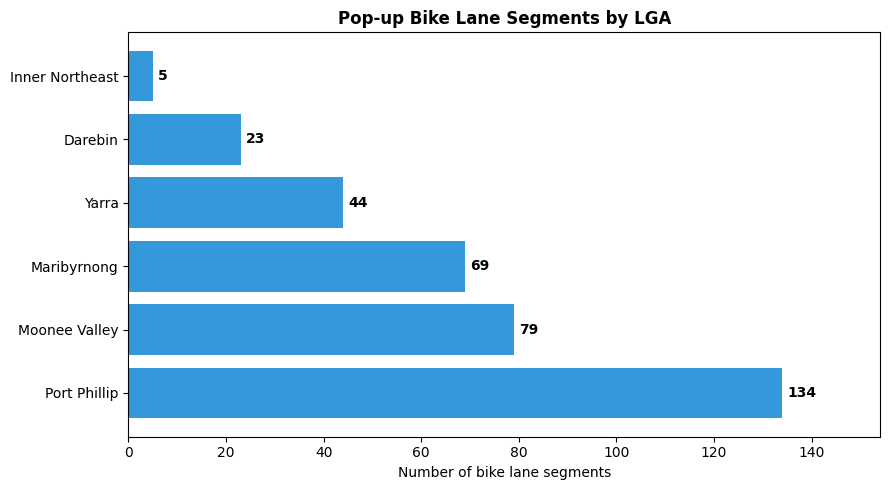

Chart saved as bike_lanes_by_lga.png


In [24]:
lga_counts = gdf['lga'].value_counts().reset_index()
lga_counts.columns = ['LGA', 'Count']

print('Bike lane segments by LGA:')
display(lga_counts)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(lga_counts['LGA'], lga_counts['Count'], color='#3498db')
ax.set_xlabel('Number of bike lane segments')
ax.set_title('Pop-up Bike Lane Segments by LGA', fontweight='bold')

for bar, count in zip(bars, lga_counts['Count']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontweight='bold')

ax.set_xlim(0, lga_counts['Count'].max() + 20)
plt.tight_layout()
plt.savefig('bike_lanes_by_lga.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as bike_lanes_by_lga.png')

## 5. Infrastructure Types — What Kind of Lanes Were Installed?

Trial infrastructure types:


,Infrastructure Type,Count
0,Shared street,192
1,Painted lane,128
2,Protected lane,23
3,Shared path,6
4,None,2
5,Shared path - dismount,2
6,Shared street - contraflow,1


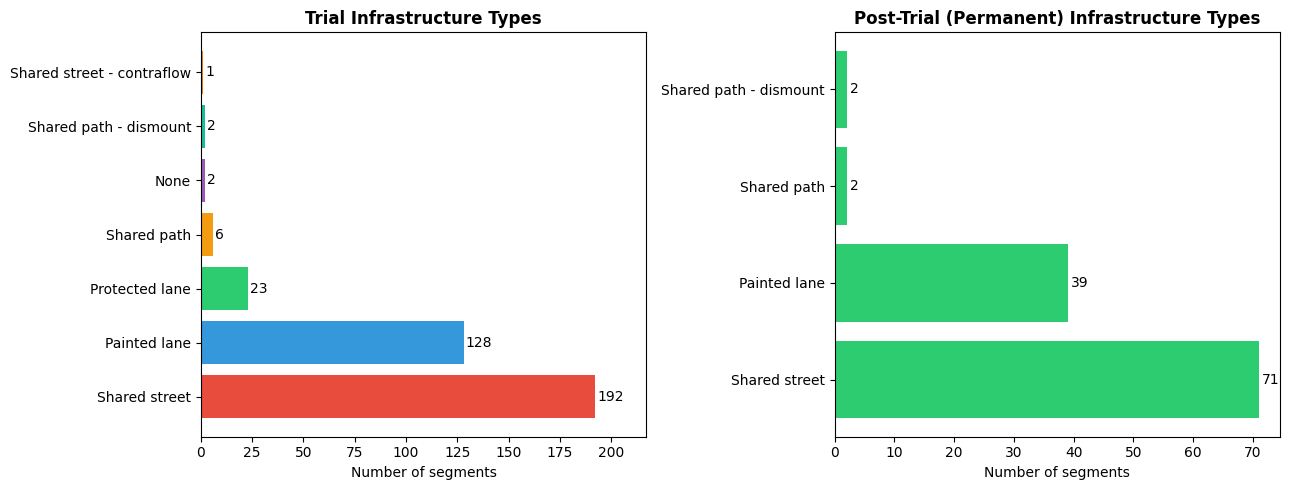

In [25]:
infra_counts = gdf['trialinfra'].value_counts().reset_index()
infra_counts.columns = ['Infrastructure Type', 'Count']

print('Trial infrastructure types:')
display(infra_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trial infrastructure
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
axes[0].barh(infra_counts['Infrastructure Type'], infra_counts['Count'],
             color=colors[:len(infra_counts)])
axes[0].set_title('Trial Infrastructure Types', fontweight='bold')
axes[0].set_xlabel('Number of segments')
for i, v in enumerate(infra_counts['Count']):
    axes[0].text(v + 1, i, str(v), va='center')
axes[0].set_xlim(0, infra_counts['Count'].max() + 25)

# Post infrastructure (what became permanent)
post = gdf[gdf['postinfra'].notna() & (gdf['postinfra'] != 'None')]
post_counts = post['postinfra'].value_counts().reset_index()
post_counts.columns = ['Infrastructure Type', 'Count']
axes[1].barh(post_counts['Infrastructure Type'], post_counts['Count'],
             color='#2ecc71')
axes[1].set_title('Post-Trial (Permanent) Infrastructure Types', fontweight='bold')
axes[1].set_xlabel('Number of segments')
for i, v in enumerate(post_counts['Count']):
    axes[1].text(v + 0.5, i, str(v), va='center')

plt.tight_layout()
plt.savefig('infrastructure_types.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Trial vs Permanent — How Many Were Made Permanent?

Trial vs Permanent breakdown:
status
Trial only (not made permanent)    240
Made permanent                     114
Name: count, dtype: int64

Percentage made permanent: 32.2%


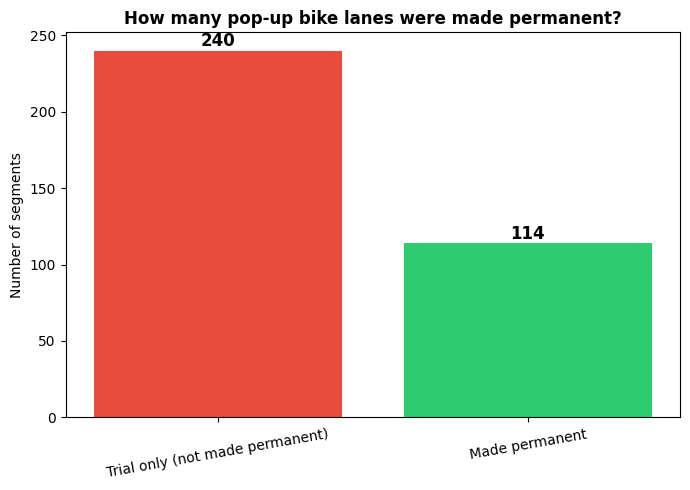

In [26]:
# classify each record
def classify_status(row):
    if pd.isna(row['postdate']) or row['postinfra'] == 'None' or pd.isna(row['postinfra']):
        return 'Trial only (not made permanent)'
    else:
        return 'Made permanent'

gdf['status'] = gdf.apply(classify_status, axis=1)
status_counts = gdf['status'].value_counts()

print('Trial vs Permanent breakdown:')
print(status_counts)
print(f'\nPercentage made permanent: {status_counts["Made permanent"] / len(gdf) * 100:.1f}%')

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(status_counts.index, status_counts.values,
              color=['#e74c3c', '#2ecc71'])
ax.set_title('How many pop-up bike lanes were made permanent?', fontweight='bold')
ax.set_ylabel('Number of segments')

for bar, count in zip(bars, status_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(count), ha='center', fontweight='bold', fontsize=12)

plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('trial_vs_permanent.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Permanent Bike Lanes by LGA

For Team B's parking analysis, the permanent bike lanes are more relevant than trial-only ones, because permanent changes are more likely to have caused lasting shifts in parking utilisation.

Permanent bike lanes by LGA:


,permanent_segments,unique_roads,infra_types
lga,,,
Port Phillip,106,28,"Shared street, Painted lane, Shared path"
Maribyrnong,4,2,"Painted lane, Shared street"
Moonee Valley,4,2,"Shared street, Shared path - dismount"


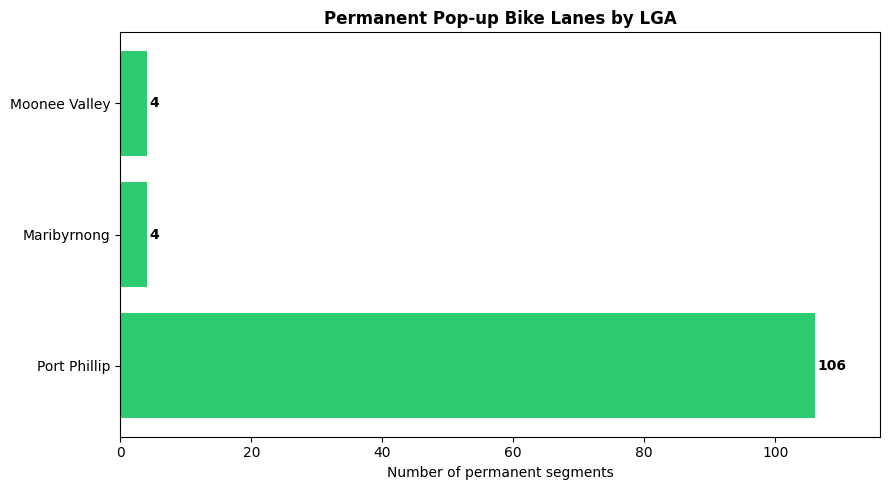

In [27]:
permanent = gdf[gdf['status'] == 'Made permanent']

perm_by_lga = permanent.groupby('lga').agg(
    permanent_segments=('fid', 'count'),
    unique_roads=('roadnm', 'nunique'),
    infra_types=('postinfra', lambda x: ', '.join(x.dropna().unique()))
).sort_values('permanent_segments', ascending=False)

print('Permanent bike lanes by LGA:')
display(perm_by_lga)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(perm_by_lga.index, perm_by_lga['permanent_segments'], color='#2ecc71')
ax.set_xlabel('Number of permanent segments')
ax.set_title('Permanent Pop-up Bike Lanes by LGA', fontweight='bold')
for bar, count in zip(bars, perm_by_lga['permanent_segments']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontweight='bold')
ax.set_xlim(0, perm_by_lga['permanent_segments'].max() + 10)
plt.tight_layout()
plt.savefig('permanent_by_lga.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Road-Level Detail — Which Roads Have Bike Lanes?

In [28]:
road_summary = gdf.groupby(['roadnm', 'lga']).agg(
    segments=('fid', 'count'),
    trial_infra=('trialinfra', 'first'),
    permanent=('status', lambda x: 'Yes' if 'Made permanent' in x.values else 'No'),
    trial_date=('trialdate', 'first')
).sort_values(['lga', 'segments'], ascending=[True, False]).reset_index()

print(f'Total unique roads with bike lanes: {road_summary["roadnm"].nunique()}')
print(f'Roads made permanent: {(road_summary["permanent"] == "Yes").sum()}')
print()
print('Road-level summary (top 20 by segment count):')
display(road_summary.head(20))

Total unique roads with bike lanes: 109
Roads made permanent: 32

Road-level summary (top 20 by segment count):


,roadnm,lga,segments,trial_infra,permanent,trial_date
0,Station Street,Darebin,8,Shared street,No,Feb-22
1,Westgarth Street,Darebin,4,Shared street,No,Feb-22
2,Jeffrey Street,Darebin,2,Painted lane,No,Feb-22
3,McLachlan Street,Darebin,2,Shared street,No,Feb-22
4,St Georges Road,Darebin,2,Shared path,No,Feb-22
5,Victoria Road,Darebin,2,Painted lane,No,Feb-22
6,Walker Street,Darebin,2,Shared street,No,Feb-22
7,Arthur Street,Darebin,1,Shared street,No,Feb-22
8,Wingrove Street,Inner Northeast,5,Shared street,No,Feb-22
9,Donald Street,Maribyrnong,10,Painted lane,No,Jul-22


## 9. Map — Geographic Distribution of Bike Lanes

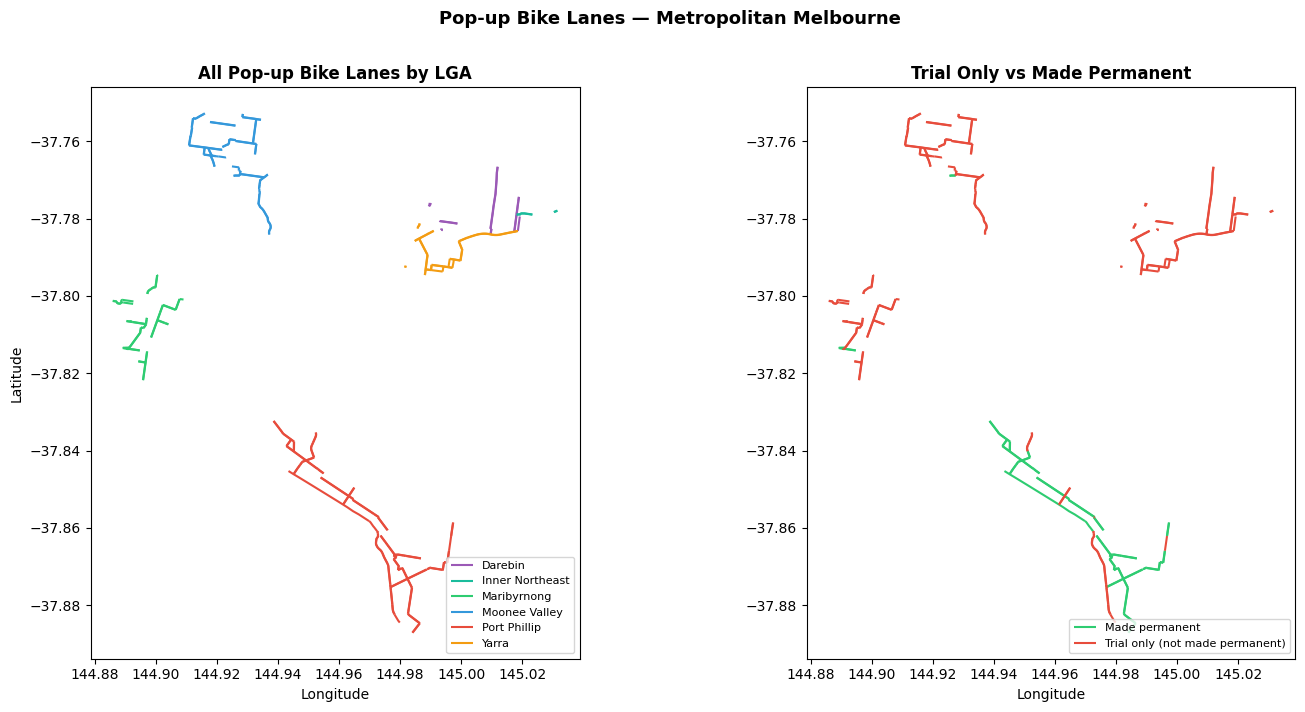

Map saved as bike_lanes_map.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Map 1: All bike lanes coloured by LGA
lga_colours = {
    'Port Phillip': '#e74c3c',
    'Moonee Valley': '#3498db',
    'Maribyrnong': '#2ecc71',
    'Yarra': '#f39c12',
    'Darebin': '#9b59b6',
    'Inner Northeast': '#1abc9c'
}
gdf['colour'] = gdf['lga'].map(lga_colours)

for lga, group in gdf.groupby('lga'):
    group.plot(ax=axes[0], color=lga_colours.get(lga, '#aaaaaa'),
               linewidth=1.5, label=lga)

axes[0].set_title('All Pop-up Bike Lanes by LGA', fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Map 2: Trial only vs permanent
colour_status = {'Trial only (not made permanent)': '#e74c3c',
                 'Made permanent': '#2ecc71'}
for status, group in gdf.groupby('status'):
    group.plot(ax=axes[1], color=colour_status[status],
               linewidth=1.5, label=status)

axes[1].set_title('Trial Only vs Made Permanent', fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].set_xlabel('Longitude')

plt.suptitle('Pop-up Bike Lanes — Metropolitan Melbourne', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bike_lanes_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Map saved as bike_lanes_map.png')

## 10. Relevance to Team B — Matching with Treatment Streets

The USIA project has 96 treatment streets in the street_spatial dataset. Once we get access to that dataset, we can match it against this Pop-up Bike Lanes dataset by road name and LGA to:

1. Confirm which treatment streets appear in this dataset
2. Extract the trial and post dates for matched streets — this gives us the construction dates needed to define before/after analysis windows
3. Identify treatment streets NOT in this dataset — these may be older interventions or ones not captured in the pop-up program, and will need dates sourced separately

**Note:** The Pop-up Bike Lanes dataset only covers 2020 onwards and is limited to metropolitan Melbourne. Regional sites (Geelong) and any pre-2020 interventions in our treatment list will not be covered here.

In [30]:
# Summary of what this dataset provides for Team B
print('=== RELEVANCE SUMMARY FOR TEAM B ===')
print(f'Total bike lane segments in dataset: {len(gdf)}')
print(f'Unique roads: {gdf["roadnm"].nunique()}')
print(f'LGAs covered: {gdf["lga"].unique().tolist()}')
print(f'Segments with trial dates: {gdf["trialdate"].notna().sum()} of {len(gdf)}')
print(f'Segments made permanent (with post dates): {(gdf["status"] == "Made permanent").sum()}')
print(f'Trial-only segments: {(gdf["status"] == "Trial only (not made permanent)").sum()}')
print()
print('Most relevant LGAs for Team B (based on PO meeting priorities):')
priority_lgas = ['Yarra', 'Port Phillip', 'Maribyrnong']
for lga in priority_lgas:
    count = len(gdf[gdf['lga'] == lga])
    perm = len(gdf[(gdf['lga'] == lga) & (gdf['status'] == 'Made permanent')])
    print(f'  {lga}: {count} total segments, {perm} permanent')

=== RELEVANCE SUMMARY FOR TEAM B ===
Total bike lane segments in dataset: 354
Unique roads: 109
LGAs covered: ['Maribyrnong', 'Port Phillip', 'Moonee Valley', 'Darebin', 'Yarra', 'Inner Northeast']
Segments with trial dates: 353 of 354
Segments made permanent (with post dates): 114
Trial-only segments: 240

Most relevant LGAs for Team B (based on PO meeting priorities):
  Yarra: 44 total segments, 0 permanent
  Port Phillip: 134 total segments, 106 permanent
  Maribyrnong: 69 total segments, 4 permanent


## 11. Key Findings

- The dataset contains **354 bike lane segments** across **6 LGAs** in metropolitan Melbourne
- **Port Phillip** has the most segments (134), followed by Moonee Valley (79) and Maribyrnong (69)
- Most lanes were trialled as **Shared Streets (192)** or **Painted Lanes (128)**. Only 23 were Protected Lanes
- **125 segments (35%)** were made permanent after the trial. The remaining 229 were trial-only
- Almost all trials happened in **2022**, with only a small number in 2021
- This dataset provides **trial dates** which are essential for defining before/after windows — but only for 2020+ interventions in metro Melbourne
- **Gaps:** Regional sites (Geelong) and pre-2020 interventions are not covered. These will need dates from other sources or directly from Infrastructure Victoria

